# Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [1]:
print("   All libraries imported successfully!") 
print("   - pandas for data handling") 
print("   - numpy for calculations") 
print("   - matplotlib & seaborn for graphs") 

   All libraries imported successfully!
   - pandas for data handling
   - numpy for calculations
   - matplotlib & seaborn for graphs


# Load The Dataset

In [4]:
print("\n" + "="*60) 
print(" STEP 1: LOADING DATASET") 
print("="*60)

df = pd.read_csv('dirty_cafe_sales.csv')
print(" Dataset loaded successfully!") 

print(f" Total Rows: {df.shape[0]}") 
print(f" Total Columns: {df.shape[1]}")

print("\n First 5 rows of raw data:") 
print(df.head())


 STEP 1: LOADING DATASET
 Dataset loaded successfully!
 Total Rows: 10000
 Total Columns: 8

 First 5 rows of raw data:
  Transaction ID    Item Quantity Price Per Unit Total Spent  Payment Method  \
0    TXN_1961373  Coffee        2            2.0         4.0     Credit Card   
1    TXN_4977031    Cake        4            3.0        12.0            Cash   
2    TXN_4271903  Cookie        4            1.0       ERROR     Credit Card   
3    TXN_7034554   Salad        2            5.0        10.0         UNKNOWN   
4    TXN_3160411  Coffee        2            2.0         4.0  Digital Wallet   

   Location Transaction Date  
0  Takeaway       2023-09-08  
1  In-store       2023-05-16  
2  In-store       2023-07-19  
3   UNKNOWN       2023-04-27  
4  In-store       2023-06-11  


# Initial Data Exploration


In [7]:
print("\n" + "="*60)
print(" STEP 2: EXPLORING THE DATA") 
print("="*60)
print("\n COLUMN INFORMATION:") 
print(df.info())
print("\n DATA TYPES OF EACH COLUMN:") 
print(df.dtypes)
print("\n📊 BASIC STATISTICS (for number columns):") 
print(df.describe())

print("\n ALL COLUMN NAMES:") 
for i, col in enumerate(df.columns): 
    print(f"   {i+1}. {col}")

print("\n CHECKING UNIQUE VALUES IN TEXT COLUMNS:")

text_columns = [] 
for col in df.columns: 
    if df[col].dtype == 'object': 
        text_columns.append(col) 
        print(f"\n Column: {col}") 
        print(f"   Unique values: {df[col].nunique()}")  
        print(f"   Sample values: {df[col].unique()[:5]}")


 STEP 2: EXPLORING THE DATA

 COLUMN INFORMATION:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9667 non-null   str  
 2   Quantity          9862 non-null   str  
 3   Price Per Unit    9821 non-null   str  
 4   Total Spent       9827 non-null   str  
 5   Payment Method    7421 non-null   str  
 6   Location          6735 non-null   str  
 7   Transaction Date  9841 non-null   str  
dtypes: str(8)
memory usage: 625.1 KB
None

 DATA TYPES OF EACH COLUMN:
Transaction ID      str
Item                str
Quantity            str
Price Per Unit      str
Total Spent         str
Payment Method      str
Location            str
Transaction Date    str
dtype: object

📊 BASIC STATISTICS (for number columns):
       Transaction ID   Item Quantity Price Per Unit Total Spent  \
count          

# Find missing values

In [9]:
print("\n" + "="*60) 
print(" STEP 3: FINDING MISSING VALUES") 
print("="*60)

missing_count = df.isnull().sum()
print("\n MISSING VALUES COUNT:") 
print(missing_count) 

missing_percent = (df.isnull().sum() / len(df)) * 100 
print("\n MISSING VALUES PERCENTAGE:") 
print(missing_percent)

missing_table = pd.DataFrame({ 
    'Column_Name': df.columns, 
    'Total_Rows': len(df), 
    'Missing_Count': missing_count.values, 
    'Missing_Percentage': missing_percent.values 
}) 

print("\n MISSING VALUES SUMMARY TABLE:") 
print(missing_table)

columns_with_missing = missing_table[missing_table['Missing_Count'] > 0] 
print("\n COLUMNS WITH MISSING VALUES:") 
if len(columns_with_missing) > 0: 
    for index, row in columns_with_missing.iterrows(): 
        print(f"   • {row['Column_Name']}: {row['Missing_Count']} missing ({row['Missing_Percentage']:.1f}%)") 
else: 
    print(" No missing values found!")


 STEP 3: FINDING MISSING VALUES

 MISSING VALUES COUNT:
Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

 MISSING VALUES PERCENTAGE:
Transaction ID       0.00
Item                 3.33
Quantity             1.38
Price Per Unit       1.79
Total Spent          1.73
Payment Method      25.79
Location            32.65
Transaction Date     1.59
dtype: float64

 MISSING VALUES SUMMARY TABLE:
        Column_Name  Total_Rows  Missing_Count  Missing_Percentage
0    Transaction ID       10000              0                0.00
1              Item       10000            333                3.33
2          Quantity       10000            138                1.38
3    Price Per Unit       10000            179                1.79
4       Total Spent       10000            173                1.73
5    Payment Method       10000           25

# Visualize Missing Values with heatmap


 STEP 4: CREATING MISSING VALUES HEATMAP

 WHAT IS A HEATMAP?
   • A heatmap uses colors to show values
   • Here: RED = missing value, BLUE = present value
   • If you see a red line/block, that column has many missing values


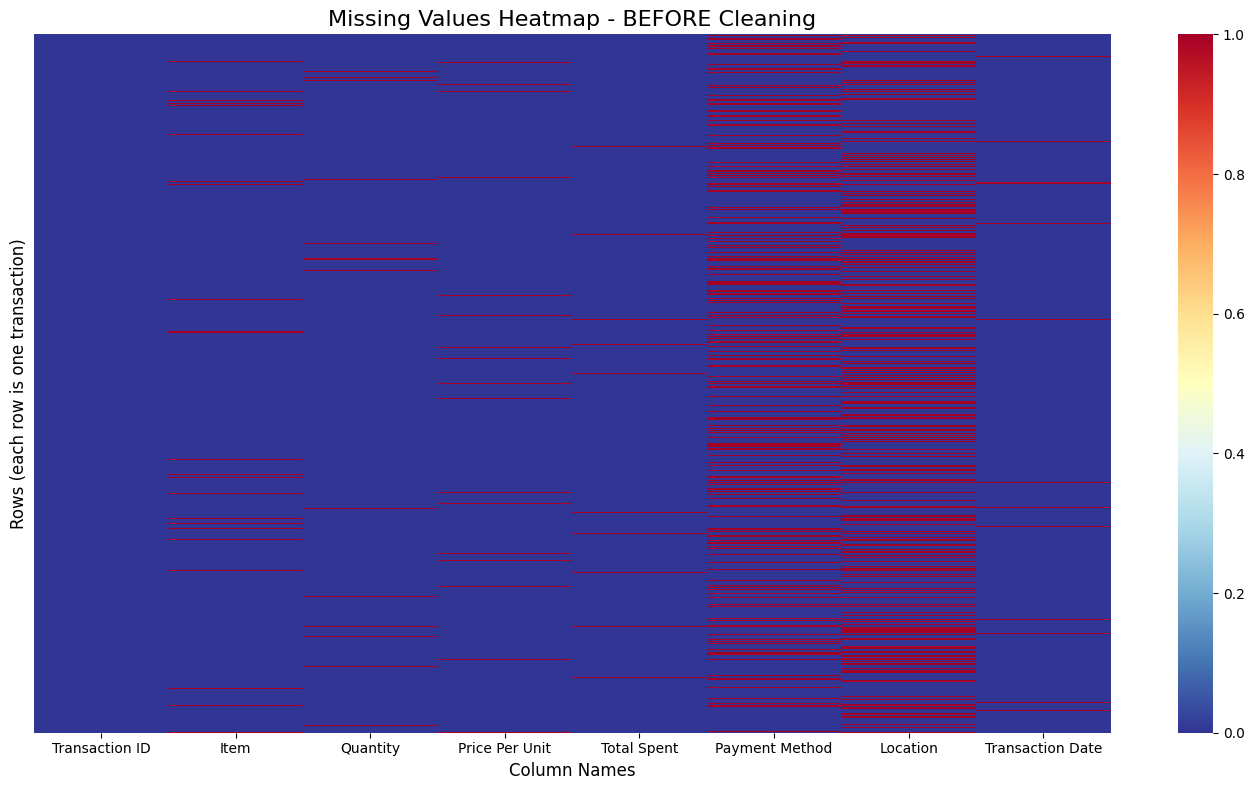


 HEATMAP INTERPRETATION:
   • RED areas = MISSING values (need attention)
   • BLUE areas = PRESENT values (data exists)
   • If a column has lots of red, it has many missing values


In [12]:
print("\n" + "="*60) 
print(" STEP 4: CREATING MISSING VALUES HEATMAP") 
print("="*60) 
 
print("\n WHAT IS A HEATMAP?") 
print("   • A heatmap uses colors to show values") 
print("   • Here: RED = missing value, BLUE = present value") 
print("   • If you see a red line/block, that column has many missing values") 
 
plt.figure(figsize=(14, 8))

sns.heatmap(df.isnull(),  
            yticklabels=False, 
            cbar=True,  
            cmap='RdYlBu_r') 

plt.title('Missing Values Heatmap - BEFORE Cleaning', fontsize=16) 
plt.xlabel('Column Names', fontsize=12) 
plt.ylabel('Rows (each row is one transaction)', fontsize=12) 
plt.tight_layout()  # Adjusts spacing to fit everything 
plt.show() 
 
print("\n HEATMAP INTERPRETATION:") 
print("   • RED areas = MISSING values (need attention)") 
print("   • BLUE areas = PRESENT values (data exists)") 
print("   • If a column has lots of red, it has many missing values")

# DROP COLUMNS WITH >50% MISSING VALUES

In [14]:
print("\n" + "="*60) 
print(" STEP 5: REMOVING COLUMNS WITH >50% MISSING VALUES") 
print("="*60) 
 
df_clean = df.copy() 
print("Created working copy of dataset") 
 
columns_to_remove = [] 
threshold = 50 
 
for column in df_clean.columns: 
    missing_percent = (df_clean[column].isnull().sum() / len(df_clean)) * 100 

    if missing_percent > threshold: 
        columns_to_remove.append(column) 
        print(f" Column '{column}' has {missing_percent:.1f}% missing - MARKED FOR REMOVAL") 

if len(columns_to_remove) > 0: 
    df_clean = df_clean.drop(columns=columns_to_remove) 
    print(f"\n Removed {len(columns_to_remove)} columns: {columns_to_remove}") 
else: 
    print("\n No columns need to be removed (all have <50% missing)") 
 
print(f"\n New dataset shape: {df_clean.shape}") 
print(f"   Rows: {df_clean.shape[0]}, Columns: {df_clean.shape[1]}") 
 
# Show remaining columns 
print("\n Remaining columns:") 
for i, col in enumerate(df_clean.columns): 
    print(f"   {i+1}. {col}") 


 STEP 5: REMOVING COLUMNS WITH >50% MISSING VALUES
Created working copy of dataset

 No columns need to be removed (all have <50% missing)

 New dataset shape: (10000, 8)
   Rows: 10000, Columns: 8

 Remaining columns:
   1. Transaction ID
   2. Item
   3. Quantity
   4. Price Per Unit
   5. Total Spent
   6. Payment Method
   7. Location
   8. Transaction Date


# SEPARATE NUMERIC AND TEXT COLUMNS

In [16]:
print("\n" + "="*60) 
print(" STEP 6: SEPARATING NUMBERS AND TEXT") 
print("="*60) 
 
number_columns = [] 
for column in df_clean.columns: 
    if df_clean[column].dtype in ['int64', 'float64']: 
        number_columns.append(column) 
 
text_columns = [] 
for column in df_clean.columns: 
    if df_clean[column].dtype == 'object': 
        text_columns.append(column) 
 
print(f"\n NUMERIC COLUMNS ({len(number_columns)} found):") 
for col in number_columns: 
    print(f"   • {col}") 
 
print(f"\n TEXT COLUMNS ({len(text_columns)} found):") 
for col in text_columns: 
    print(f"   • {col}") 

print("\n CHECKING FOR NUMBERS STORED AS TEXT:") 
for col in text_columns: 
    sample = df_clean[col].dropna().iloc[:5] if len(df_clean[col].dropna()) > 0 else [] 
    could_be_numeric = False 
    for val in sample: 
        try: 
            float(val) 
            could_be_numeric = True 
        except: 
            pass 
     
    if could_be_numeric: 
        print(f"   • {col}: Might contain numbers stored as text") 


 STEP 6: SEPARATING NUMBERS AND TEXT

 NUMERIC COLUMNS (0 found):

 TEXT COLUMNS (0 found):

 CHECKING FOR NUMBERS STORED AS TEXT:


# CHECK FOR AND FIX DATA TYPES

In [17]:
print("\n" + "="*60) 
print(" STEP 7: FIXING DATA TYPES") 
print("="*60) 
 
if 'Price_Per_Unit' in df_clean.columns: 
    print("\n Fixing Price_Per_Unit column:") 
     
    print("   Current sample values:") 
    for val in df_clean['Price_Per_Unit'].dropna().head(5): 
        print(f"      • {val}") 
     
    df_clean['Price_Per_Unit'] = df_clean['Price_Per_Unit'].astype(str).str.replace('$', '') 
    df_clean['Price_Per_Unit'] = df_clean['Price_Per_Unit'].str.replace(' ', '') 
     
    df_clean['Price_Per_Unit'] = pd.to_numeric(df_clean['Price_Per_Unit'], errors='coerce') 
     
    print("   Converted to proper numbers") 
    print("   New sample values:") 
    for val in df_clean['Price_Per_Unit'].dropna().head(5): 
        print(f"      • {val}") 
 
if 'Quantity' in df_clean.columns: 
    print("\n Fixing Quantity column:") 
     
    df_clean['Quantity'] = pd.to_numeric(df_clean['Quantity'], errors='coerce') 
    print("    Converted to proper numbers") 
 
if 'Total_Spent' in df_clean.columns: 
    print("\n Fixing Total_Spent column:") 
     
    df_clean['Total_Spent'] = df_clean['Total_Spent'].replace('ERROR', np.nan) 
     
    df_clean['Total_Spent'] = pd.to_numeric(df_clean['Total_Spent'], errors='coerce') 
    print("   Converted to proper numbers, 'ERROR' replaced with NaN") 
 
print("\n Updated data types:") 
print(df_clean.dtypes) 
 
number_columns = [] 
for column in df_clean.columns: 
    if df_clean[column].dtype in ['int64', 'float64']: 
        number_columns.append(column) 
 
text_columns = [] 
for column in df_clean.columns: 
    if df_clean[column].dtype == 'object': 
        text_columns.append(column) 
 
print(f"\n Updated - Numeric columns: {number_columns}") 
print(f" Updated - Text columns: {text_columns}") 


 STEP 7: FIXING DATA TYPES

 Fixing Quantity column:
    Converted to proper numbers

 Updated data types:
Transaction ID          str
Item                    str
Quantity            float64
Price Per Unit          str
Total Spent             str
Payment Method          str
Location                str
Transaction Date        str
dtype: object

 Updated - Numeric columns: ['Quantity']
 Updated - Text columns: []


#  HANDLE MISSING NUMERIC VALUES - METHOD 1 
(MEAN)

In [18]:
print("\n" + "="*60) 
print(" STEP 8: FILLING NUMERIC MISSING VALUES - METHOD 1 (MEAN)") 
print("="*60) 
 
print("\n WHAT IS MEAN?") 
print("   • Mean = sum of all values ÷ number of values") 
print("   • Example: [2, 4, 6, 8] → mean = (2+4+6+8)÷4 = 20÷4 = 5") 
print("   • Best when data is normally distributed (bell curve)") 
print("   • Can be skewed by extreme outliers") 
 
df_mean = df_clean.copy() 
 
for column in number_columns: 
    if column in df_mean.columns: 
        missing_count = df_mean[column].isnull().sum() 
         
        if missing_count > 0: 
            print(f"\n  Column: {column}") 
            print(f"   Missing values: {missing_count}") 
             
            mean_value = df_mean[column].mean() 
            print(f"   Mean value: {mean_value:.2f}") 
             
            print("   Values before (sample):") 
            sample_values = df_mean[column].dropna().head(3) 
            for val in sample_values: 
                print(f"      • {val}") 
             
            df_mean[column].fillna(mean_value, inplace=True) 
             
            print(f"    Filled {missing_count} missing values with MEAN: {mean_value:.2f}") 
            print(f"    No missing values remain: {df_mean[column].isnull().sum()}")


 STEP 8: FILLING NUMERIC MISSING VALUES - METHOD 1 (MEAN)

 WHAT IS MEAN?
   • Mean = sum of all values ÷ number of values
   • Example: [2, 4, 6, 8] → mean = (2+4+6+8)÷4 = 20÷4 = 5
   • Best when data is normally distributed (bell curve)
   • Can be skewed by extreme outliers

  Column: Quantity
   Missing values: 479
   Mean value: 3.03
   Values before (sample):
      • 2.0
      • 4.0
      • 4.0
    Filled 479 missing values with MEAN: 3.03
    No missing values remain: 479
